# DBSCAN 

## Данные: Wholesale customers Data Set


Источник данных: https://archive.ics.uci.edu/ml/datasets/Wholesale+customers


Описание атрибутов:

    1) FRESH: расходы за год на свежие продукты (непрерывная переменная);
    2) MILK: расходы за год на молочные продукты (непрерывная переменная);
    3) GROCERY: расходы за год на продовольственные товары / бакалея (непрерывная переменная);
    4) FROZEN: расходы за год на замороженные продукты (непрерывная переменная)
    5) DETERGENTS_PAPER: расходы за год на моющие средства и бумажные изделия (непрерывная переменная)
    6) DELICATESSEN: расходы за год на деликатесы (непрерывная переменная);
    7) CHANNEL: канал клиента - индустрия общественного питания Horeca (отели/рестораны/кафе) или розничный канал Retail (Категориальная переменная)
    8) REGION: регион клиента - Lisnon, Oporto или Other (Категориальная переменная)
 

Исходные статьи:

Cardoso, Margarida G.M.S. (2013). Logical discriminant models â€“ Chapter 8 in Quantitative Modeling in Marketing and Management Edited by Luiz Moutinho and Kun-Huang Huarng. World Scientific. p. 223-253. ISBN 978-9814407717

Jean-Patrick Baudry, Margarida Cardoso, Gilles Celeux, Maria JosÃ© Amorim, Ana Sousa Ferreira (2012). Enhancing the selection of a model-based clustering with external qualitative variables. RESEARCH REPORT NÂ° 8124, October 2012, Project-Team SELECT. INRIA Saclay - ÃŽle-de-France, Projet select, UniversitÃ© Paris-Sud 11



-----

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wholesome_customers_data.csv')

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
df['Channel'].unique()

array([2, 1], dtype=int64)

In [8]:
df['Region'].unique()

array([3, 1, 2], dtype=int64)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


## Исследование данных (EDA - Exploratory Data Analysis)

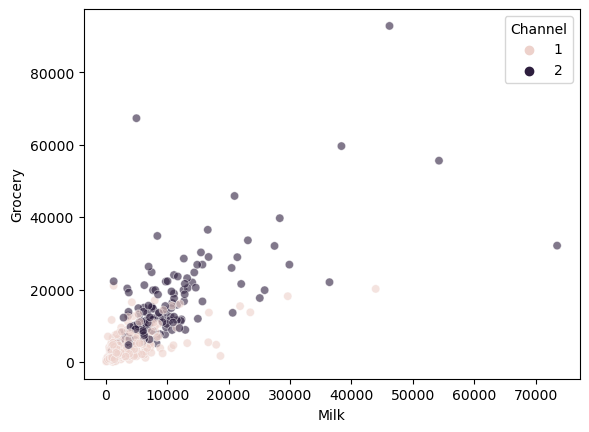

In [33]:
sns.scatterplot(data=df,x='Milk',y='Grocery',hue='Channel',alpha=0.6);

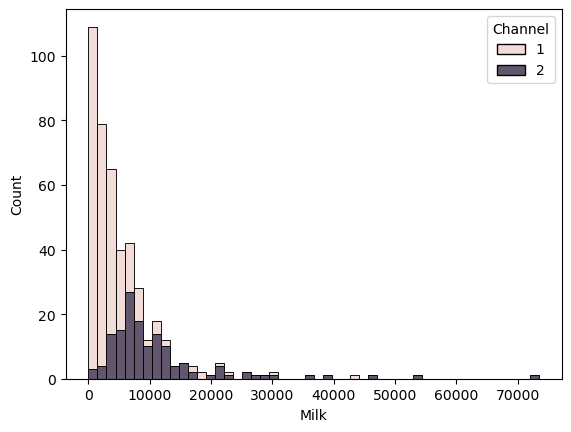

In [14]:
sns.histplot(data=df,x='Milk',hue='Channel',multiple='stack');

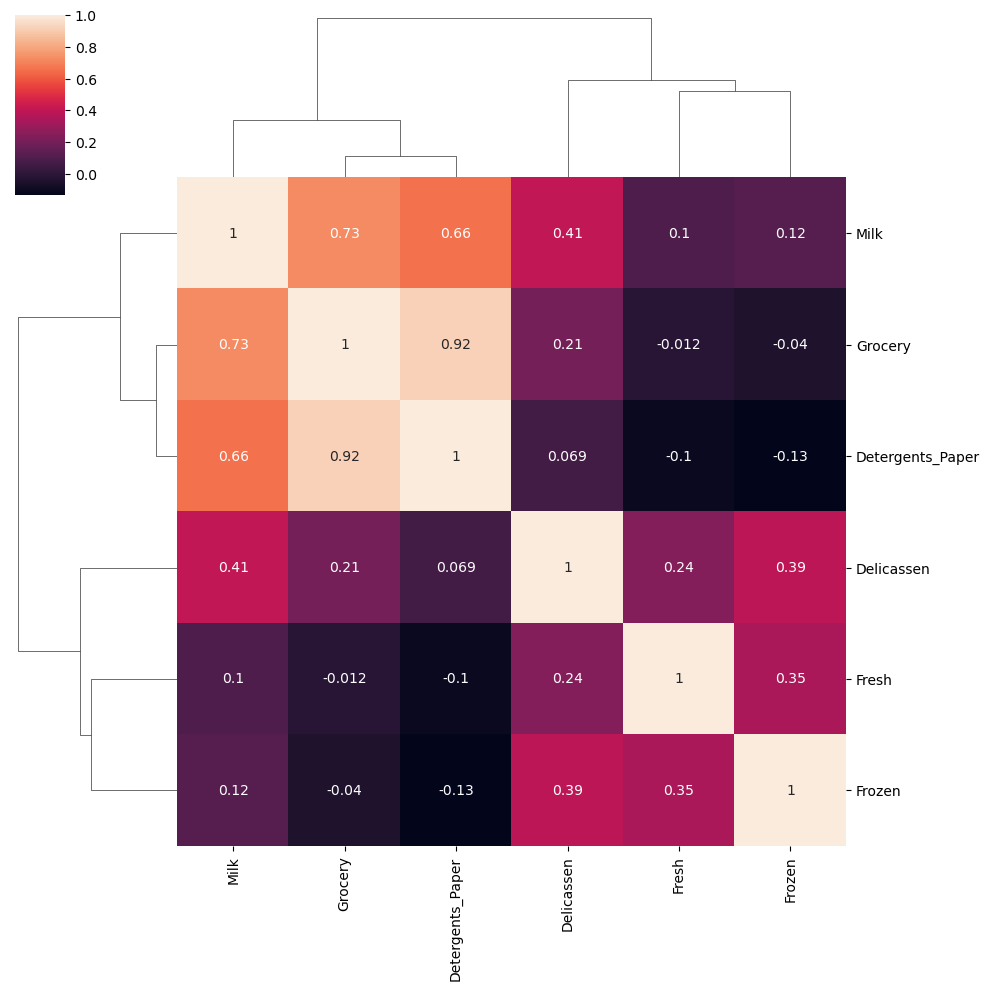

In [17]:
sns.clustermap(df.drop(['Channel','Region'],axis=1).corr(),annot=True);

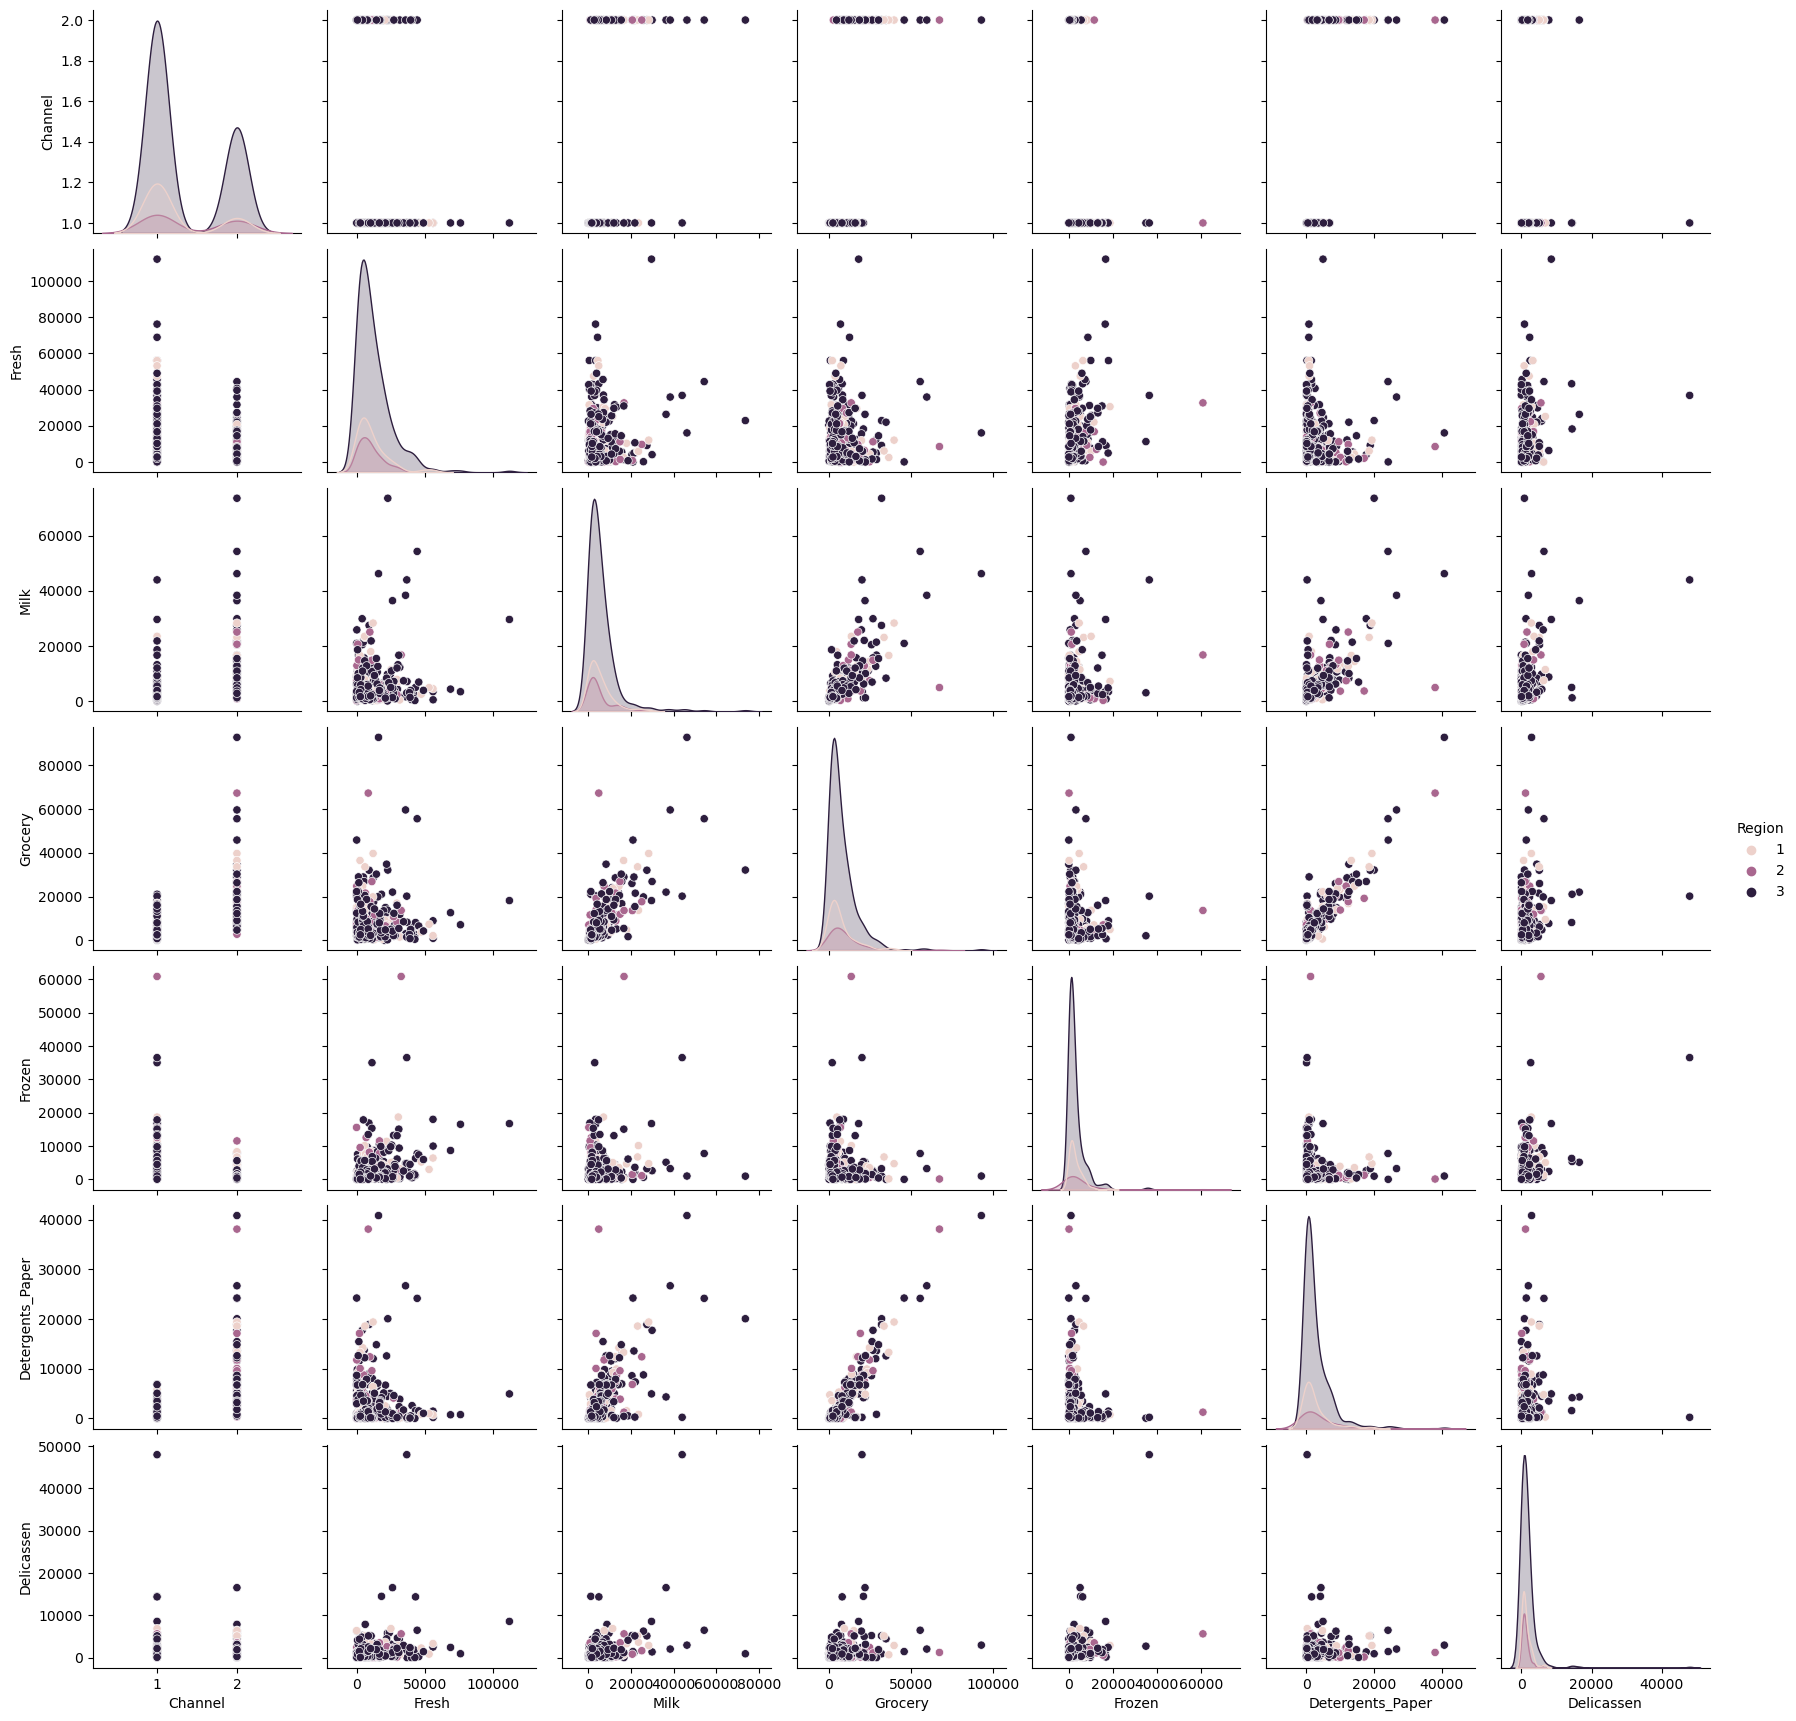

In [18]:
sns.pairplot(df,hue='Region');

## Модель

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [20]:
sdf = scaler.fit_transform(df)

In [21]:
from sklearn.cluster import DBSCAN

In [40]:
out_perc = []

for e in np.linspace(0.001,3,50):
    model = DBSCAN(eps=e,min_samples=16)
    labels = model.fit_predict(sdf)
    
    out_perc.append(100 * np.sum(labels == -1) / len(df))

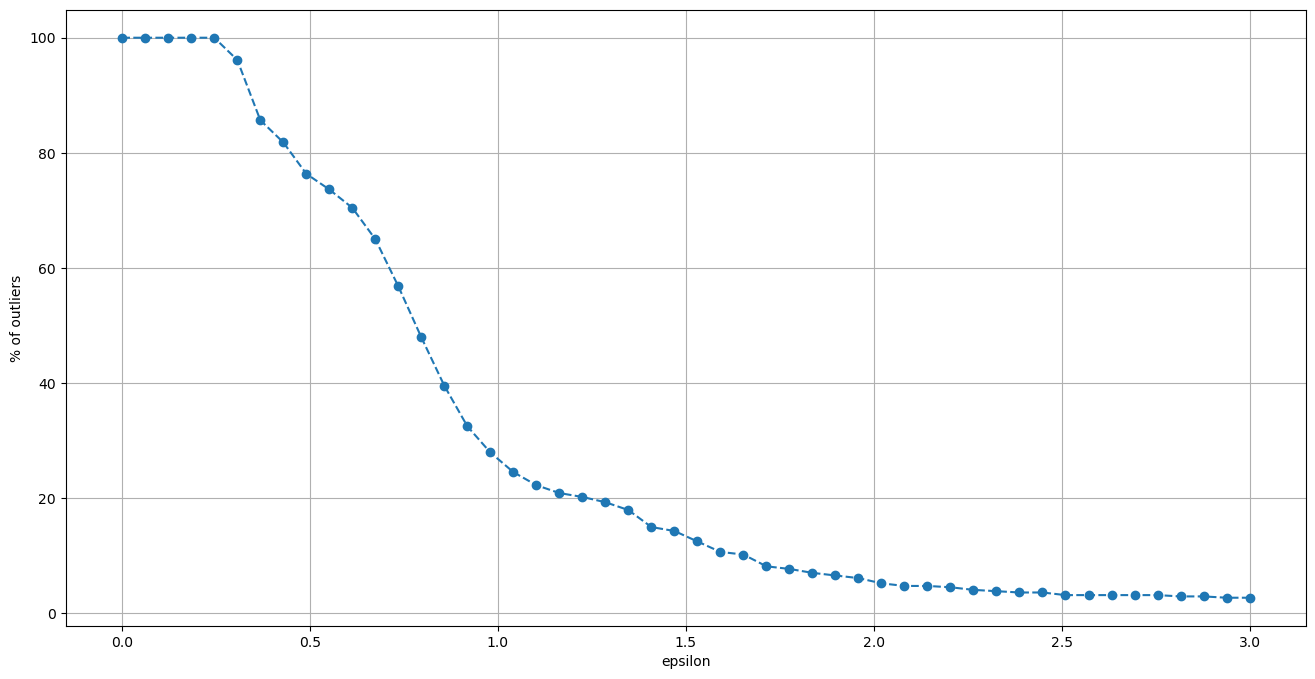

In [41]:
plt.figure(figsize=(16,8))
plt.plot(np.linspace(0.001,3,50),out_perc,'o--')
plt.xlabel('epsilon')
plt.ylabel('% of outliers')
plt.grid(True);

### DBSCAN для выбранного значения эпсилон


In [42]:
dbscan = DBSCAN(eps=1.75,min_samples=16)

In [43]:
dbscan.fit(sdf)

DBSCAN(eps=1.75, min_samples=16)

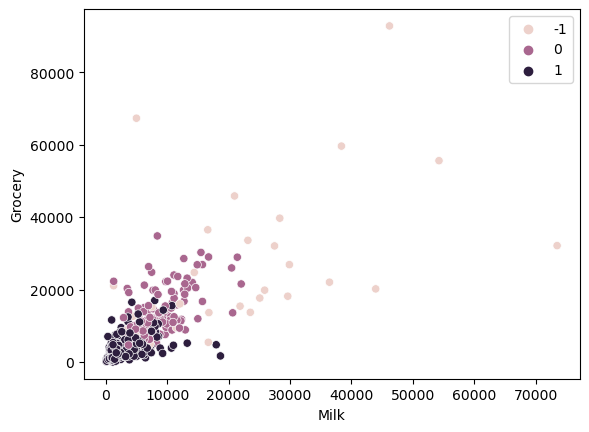

In [45]:
sns.scatterplot(data=df,x='Milk',y='Grocery',hue=dbscan.labels_);

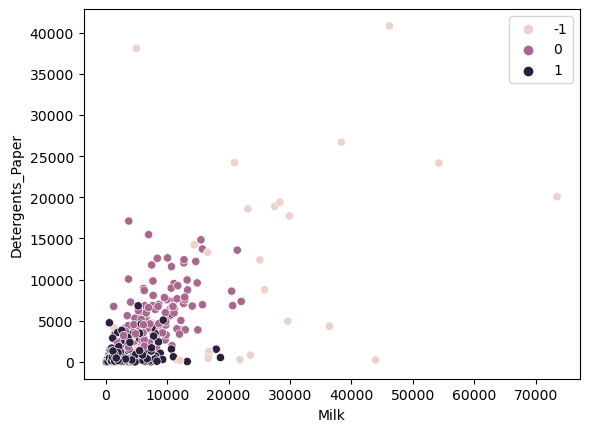

In [46]:
sns.scatterplot(data=df,x='Milk',y='Detergents_Paper',hue=dbscan.labels_);

In [47]:
df['Labels'] = dbscan.labels_

In [48]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Labels
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0
...,...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204,-1
436,1,3,39228,1431,764,4510,93,2346,1
437,2,3,14531,15488,30243,437,14841,1867,0
438,1,3,10290,1981,2232,1038,168,2125,1


In [51]:
df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen','Labels']].groupby('Labels').mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Labels,,,,,,
-1,27370.722222,19274.611111,22685.888889,9769.194444,9107.694444,5459.138889
0,8334.709677,8402.282258,13614.830645,1389.508065,5841.717742,1458.161290
1,11647.432143,2909.242857,3548.682143,2955.928571,770.025000,1048.578571


In [52]:
from sklearn.preprocessing import MinMaxScaler

In [53]:
mscaler = MinMaxScaler()

In [56]:
pd.DataFrame(mscaler.fit_transform(df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen','Labels']].groupby('Labels').mean()),columns=['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen'],index=[-1,0,1])

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
-1,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
0,0.000000,0.33565,0.525999,0.000000,0.608287,0.092864
1,0.174024,0.00000,0.000000,0.186931,0.000000,0.000000


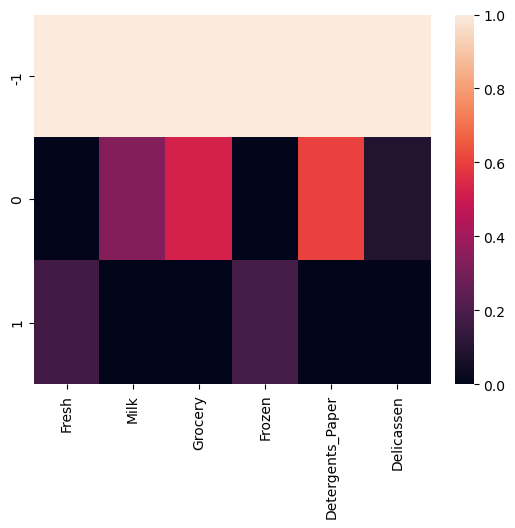

In [58]:
sns.heatmap(pd.DataFrame(mscaler.fit_transform(df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen','Labels']].groupby('Labels').mean()),columns=['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen'],index=[-1,0,1]));

# Выводы:

DBSCAN с параметрами eps=1.75 и min_samples=16 позволил выделить в данных о расходах клиентов три интерпретируемые группы: кластер 0 (розничные клиенты с высокими тратами на молочные продукты, бакалею и моющие средства), кластер 1 (предприятия общепита с приоритетом на свежие и замороженные продукты) и выбросы (крупные оптовые покупатели с аномально высокими расходами по всем категориям), при этом предварительный разведочный анализ подтвердил сильную корреляцию между Milk, Grocery и Detergents_Paper, а также позволил визуально оценить распределения и наличие аномалий, что в совокупности демонстрирует применимость DBSCAN для сегментации клиентов без необходимости задавать число кластеров заранее.